In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

In [2]:
EMBEDDINGS_PATH = "../embeddings/shoe_image_embeddings_finetuned_v1.npy"
FILENAMES_PATH = "../embeddings/shoe_image_filenames_v1.npy"

TRAIN_CSV = "../datasets/splits/train_images.csv"

RANDOM_STATE = 42

In [3]:
embeddings = np.load(EMBEDDINGS_PATH)

print("Embedding shape:", embeddings.shape)

Embedding shape: (1848, 256)


In [4]:
filenames = np.load(
    FILENAMES_PATH,
    allow_pickle=True
)

train_df = pd.read_csv(TRAIN_CSV)

print("Embeddings:", len(embeddings))
print("Filenames:", len(filenames))
print("Train rows:", len(train_df))

Embeddings: 1848
Filenames: 1848
Train rows: 1848


In [5]:
brand_map = dict(
    zip(
        train_df["image_name"],
        train_df["brand"]
    )
)

brands = np.array([
    brand_map[name]
    for name in filenames
])

print("Brands:", len(brands))
print(pd.Series(brands).value_counts())

Brands: 1848
vans           643
puma           383
nike           265
reebok         239
underarmour    160
newbalance     158
Name: count, dtype: int64


In [6]:
missing = [
    name
    for name in filenames
    if name not in brand_map
]

print("Missing labels:", len(missing))

if missing:
    print(missing[:10])

Missing labels: 0


In [7]:
norms = np.linalg.norm(
    embeddings,
    axis=1
)

print("Minimum norm:", norms.min())
print("Maximum norm:", norms.max())
print("Mean norm:", norms.mean())

Minimum norm: 0.9999999
Maximum norm: 1.0000001
Mean norm: 1.0


In [8]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)

embeddings_2d = tsne.fit_transform(embeddings)

print("t-SNE shape:", embeddings_2d.shape)

t-SNE shape: (1848, 2)


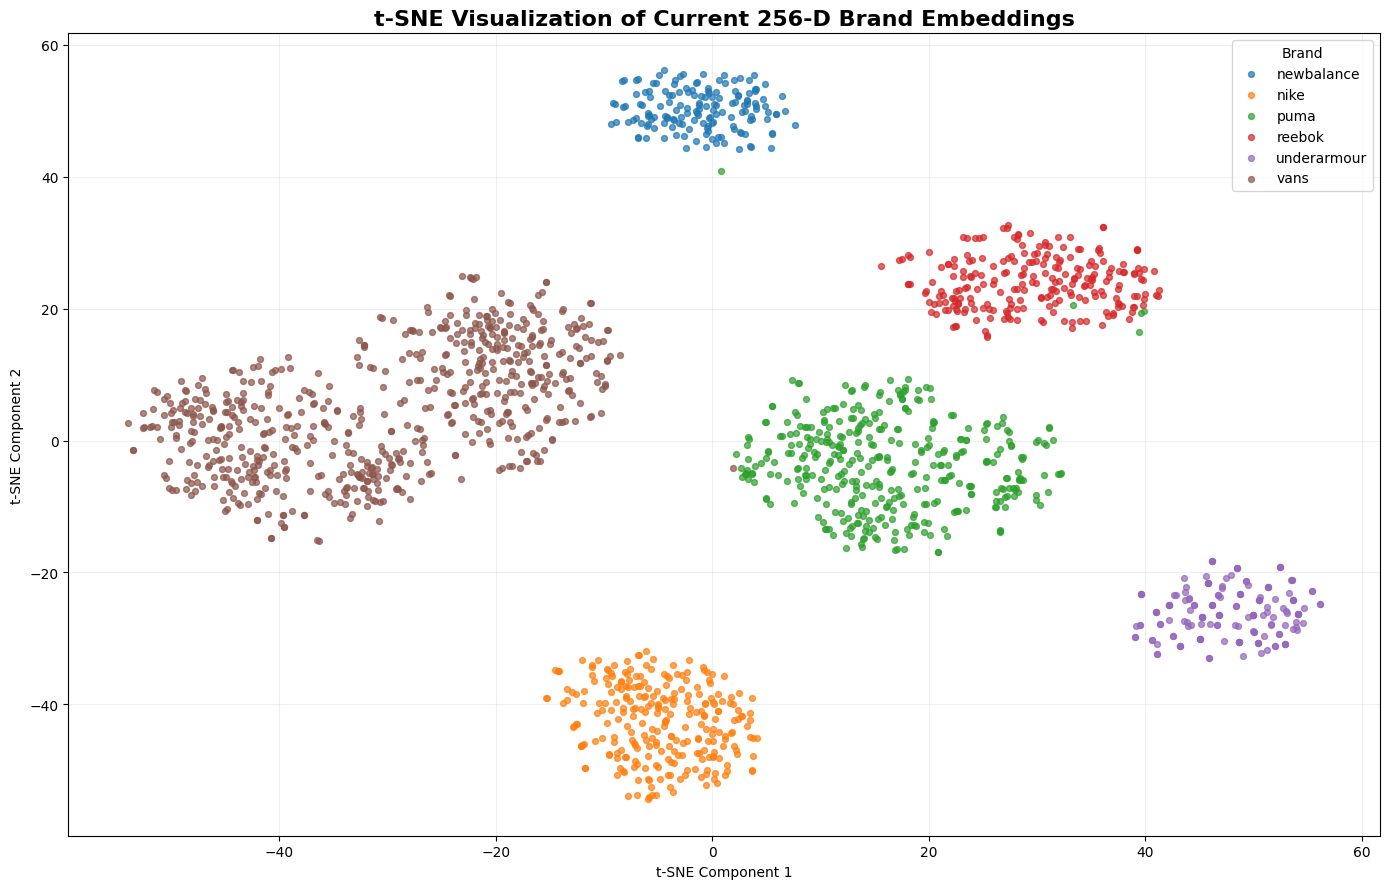

In [9]:
plt.figure(figsize=(14, 9))

for brand in sorted(np.unique(brands)):

    mask = brands == brand

    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=brand,
        s=18,
        alpha=0.7
    )

plt.title(
    "t-SNE Visualization of Current 256-D Brand Embeddings",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.legend(
    title="Brand",
    loc="upper right"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()